## Financial Sentiment Analysis
 <p>
 WMG9B7-15 - Artificial Intelligence & Deep Learning<br>
 u5696284<br>
 A sentiment analysis using Twitter Financial News dataset.
 <p>

### Phase 0: Setup & Environment

In [56]:
%pip install ipykernel numpy pandas matplotlib scikit-learn transformers datasets evaluate torch ipywidgets -q

Note: you may need to restart the kernel to use updated packages.


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import torch
from datasets import load_dataset
import re

In [58]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### Phase 1: Data Loading & Exploration

In [59]:
ds = load_dataset("zeroshot/twitter-financial-news-sentiment")

In [60]:
print(ds)
# Splitting ds into training and testing dataset
train_data = ds['train']
test_data = ds['validation']

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9543
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2388
    })
})


**Label Mapping:**
- 0: Bearish
- 1: Bullish
- 2: Neutral

In [61]:
# Converting train and test python dict to pandas dataframe
train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

In [62]:
print(train_df.shape)
print(test_df.shape)

(9543, 2)
(2388, 2)


In [63]:
train_df.head()

,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0


In [64]:
label_map = {0:'Bearish', 1:'Bullish', 2:'Neutral'}
for label_id, label_name in label_map.items():
    idx = train_df[train_df['label'] == label_id].index[50]
    print(f"\nLabel {label_id} ({label_name}) at index {idx}")
    print(train_df.loc[idx, "text"])


Label 0 (Bearish) at index 50
Canada Goose stock price target cut to $50 from $65 at CFRA

Label 1 (Bullish) at index 176
Analysts See 18% Gains Ahead For The Holdings Of The First Trust Dow Jones Internet Index Fund ETF

Label 2 (Neutral) at index 446
Bank of Israel expands its crisis QE with $13.6 billion in bond buying https://t.co/xEMWn1vjAO


In [65]:
train_df.dtypes # Checking type of data

text       str
label    int64
dtype: object

In [66]:
train_df.duplicated().sum()  # Returns number of duplicate rows

np.int64(0)

In [67]:
train_df.isna().sum() # Checking for missing values

text     0
label    0
dtype: int64

In [68]:
counts = train_df["label"].value_counts().rename(index=label_map)
pct = train_df["label"].value_counts(normalize=True).mul(100).rename(index=label_map)

summary = pd.DataFrame({"count": counts, "percentage": pct})
print(summary)

         count  percentage
label                     
Neutral   6178   64.738552
Bullish   1923   20.150896
Bearish   1442   15.110552


<p>Class imbalance identified. It can be observed that ~65% of the dataset is made up of neutral statements while the Bullish and Bearish statements are only 20% and 15% respectively. This could result in a misleading accuracy where the model accurately predicts the majority class to achieve artificially high scores despite failing to identify the minority class. In this case, precision and recall are better metrics to know how well the model identifies the minority classes but a better option would be F1 Score as it is a harmonic mean of both Precision and Recall and we would specifically use Macro F1 Score as it treats all classes equally, making it superior for imbalanced datasets where minority class performance matters.<br>For model training, can consider class_weight = 'balanced' for the baseline and weighted loss for FinBERT.</p>

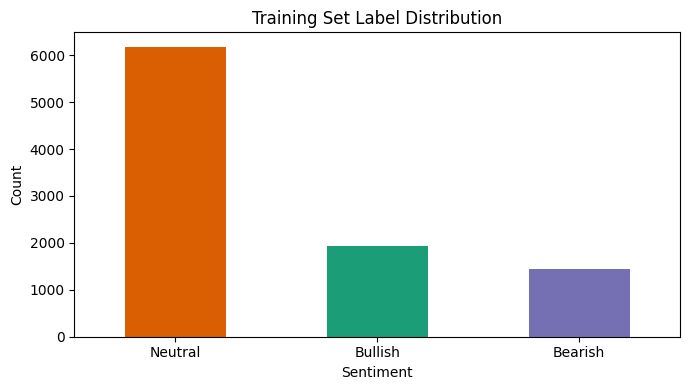

In [69]:
# Plot: Label distribution
label_map = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
label_counts = train_df["label"].map(label_map).value_counts()

plt.figure(figsize=(7, 4))
label_counts.plot(kind="bar", color=["#d95f02", "#1b9e77", "#7570b3"])
plt.title("Training Set Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Phase 2: TF-IDF + Logistic Regression (Baseline)

In [70]:
# Text Cleaning using RegEx
# Normalize tweet text for modeling by removing cashtags/URLs/mentions, stripping symbols,
# and lowercasing so the sentiment model learns from consistent headline words.

def clean_tweet_headline(text: str) -> str:
    text = re.sub(r'\$\w+', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.strip()

train_df['text'] = train_df['text'].apply(clean_tweet_headline)
test_df['text'] = test_df['text'].apply(clean_tweet_headline)

In [71]:
# Sanity Test
label_map = {0:'Bearish', 1:'Bullish', 2:'Neutral'}
for label_id, label_name in label_map.items():
    idx = train_df[train_df['label'] == label_id].index[50]
    print(f"\nLabel {label_id} ({label_name}) at index {idx}")
    print(train_df.loc[idx, "text"])


Label 0 (Bearish) at index 50
canada goose stock price target cut to  from  at cfra

Label 1 (Bullish) at index 176
analysts see  gains ahead for the holdings of the first trust dow jones internet index fund etf

Label 2 (Neutral) at index 446
bank of israel expands its crisis qe with  billion in bond buying


<p>The cashtags, URLs, and mentions have been removed. Lowercase has been applied. Punctuation stripped.<br>Limitation: the cleaning function also removes any numbers mentioned as percentages which is why you see gaps like "cut to  from  at"</p>